# Nedelec edge elements and waveguide computations

This code implements Nedelec elements and demonstrates their use to to compute the eigenmodes/eigenvalues of waveguides. In terms of notation, we follow here the textbook Davidson, Computational Electromagnetics for RF and Microwave Engineering. The most important difference is that a local index of a local Nedelec element is corresponding to the local index of the opposite vertex. Furthermore, we assume that the directed edges are given in a counter-clockwise sense. 

Actually, this is exactly how Rylander et al do it for the rectangular elements (see Fig. 6.14 in chapter 6.5) and how they do it when they introduce the reference element in chapter 6.6.1. They do not adhere to there own system in chapter 6.5.5 (see also Fig. 6.23, where the edges are not properly aligned). What is more, Rylander's derivation of the matrices in (6.70) and in (6.71) is in my view incomplete and not very elegant. For all those reasons, I follow rather Davidson, who is far more adhering to the standards.

In [1]:
"""
    generate_mesh(filename, h; verbosity=0)

    Generates a mesh with mesh size `h` using GMSH with a `.geo` input file `filename`.
    The mesh is saved in msh2 format as `filename.msh`.
    Note that this function requires gmsh to be callable via the command line!
"""
function generate_mesh(filename, h; verbosity=0)
    # -2: 2d mesh generation
    # -clscale sets the mesh size factor, that is, the average edge length h
    # -format: we are here using the slightly older MSH2 format
    # -v: level of verbosity
    # run gmsh -help in the command line to learn about the details 
    # or consult the online help<
    run(`gmsh $filename -2 -clscale $h -format msh2 -v $verbosity`)
end

"""
    generate_rectangle(filename, h; verbosity=0)

    Generates a mesh of a rectangle [-`a`/2, `a`/2]x[-`b`, `b`/2] with mesh size `h` using GMSH.
    The mesh is saved in msh2 format as `rectangle.msh`.
    Note that this function requires gmsh to be callable via the command line!
"""
function generate_rectangle(a, b, h; verbosity=0)
    # -2: 2d mesh generation
    # -clscale sets the mesh size factor, that is, the average edge length h
    # -format: we are here using the slightly older MSH2 format
    # -v: level of verbosity
    # run gmsh -help in the command line to learn about the details 
    # or consult the online help
    run(`gmsh rectangle.geo -2 -clscale $h -setnumber a $a -setnumber b $b -format msh2 -v $verbosity`)
end

generate_rectangle

In [3]:
using StaticArrays
using DelimitedFiles
using Test

"""
    Mesh{U,D,F,I}

Type to store GMSH mesh.

# Fields
- `vertices::Vector{SVector{U, F}}`: stores the vertices
- `triangles::Vector{SVector{D, I}}`: stores the triangles of the mesh
"""
mutable struct Mesh{U, D, I <: Integer, F <: Real}
    vertices::Vector{SVector{U, F}}
    triangles::Vector{SVector{D, I}}
end

function getvertices(Γ::Mesh)
    return Γ.vertices
end

function numvertices(Γ::Mesh)
    return length(Γ.vertices)
end

function gettriangles(Γ::Mesh)
    return Γ.triangles
end

function numtriangles(Γ::Mesh)
    return length(Γ.triangles)
end

function read_gmsh(fn::AbstractString; universedimension=3)
    open(fn, "r") do io  
        return read_gmsh(io, universedimension)
    end
end
    
function read_gmsh(io, universedimension)
    # The '|>' operator is documented in the 
    # 'Essentials' section of the Julia manual
    thisLine = io |> readline |> strip 
        
    while thisLine != "\$Nodes" # We need to escape the '$'
        thisLine = io |> readline |> strip        end

    thisLine = io |> readline |> strip
    s = split(thisLine)
    NV = parse(Int, s[1])
    
    P = SVector{universedimension, Float64}
    v = Vector{P}(undef,NV)
    # Read in vertices
    for i in 1:NV
        thisLine = io |> readline |>  strip
        d = readdlm(IOBuffer(thisLine), Float64)
        # Format of each line: node-number x-coord y-coord z-coord
        if universedimension == 2
            v[i] = P(d[2], d[3])
        else
            v[i] = P(d[2], d[3], d[4])
        end
    end

    while thisLine != "\$Elements"
        thisLine = io |> readline |> strip
    end

    thisLine = io |> readline |> strip

    s = split(thisLine)
    NE = parse(Int, s[1])

    thisLine = io |> readline |> strip
    I2 = SVector{2,Int}
    I3 = SVector{3,Int}
    l = Vector{I2}(undef,NE)
    lp = Vector{Int}(undef,NE)
    f = Vector{I3}(undef,NE)
    lc = 0 # Lines' counter
    fc = 0 # triangles' counter
    # Read in elements
    for i=1:NE
        # Format of each line: 
        # elm-number elm-type number-of-tags < tag > … node-number-list
        d = readdlm(IOBuffer(thisLine), Int)
        thisLine = io |> readline |> strip
        
        if d[2] == 1 
            l[lc+=1] = d[end-1:end]
            
            if d[3] == 2 # Ensure that there are two tags, the first being the physical tag
                lp[lc] = d[4] # Physical tag is always the first tag
            else
                error("We require each part of the boundary to be associated with a physical group")
            end
        end
        
        if d[2] == 2 # elm-type must be 3-node triangle
            f[fc+=1] = d[end-2:end] # Last three entries per line are the nodes of the triangle
        end
    end
    resize!(l,lc)
    resize!(lp,lc)
    resize!(f,fc)

    return Mesh{universedimension, 3, Int, Float64}(v, f)
end

universedimension(space::Mesh{U, D, I, F}) where {U, D, I, F} = U
integertype(space::Mesh{U, D, I, F}) where {U, D, I, F} = I
vertextype(space::Mesh{U, D, I, F}) where {U, D, I, F} = F
dimension(space::Mesh{U, D, I, F}) where {U, D, I, F} = D

"""
    generate_reftriangle()

Generates a reference triangle to test the implementation of Nedelec elements.
"""
function generate_reftriangle()
    vertices = [
        SVector(0.0, 1.0, 0.0),
        SVector(-0.5, 0.0, 0.0),
        SVector(+0.5, 0.0, 0.0)
    ]
    
    triangles = [
        SVector(1, 2, 3)
    ]
    @show typeof(triangles)
    return Mesh{3, 3, Int, Float64}(vertices, triangles)
end

Ω = generate_reftriangle()

@test universedimension(Ω)==3
@test dimension(Ω)==3 # We deal with triangles

"""
    generate_refpair()

Generates a reference pair of triangles to test the implementation of Nedelec elements.
"""
function generate_refpair()
    vertices = [
        SVector(0.0, 1.0, 0.0),
        SVector(-0.5, 0.0, 0.0),
        SVector(+0.5, 0.0, 0.0),
        SVector(0.0, -1.0, 0.0)
    ]
    
    triangles = [
        SVector(1, 2, 3),
        SVector(2, 4, 3)
    ]
    @show typeof(triangles)
    return Mesh{3, 3, Int, Float64}(vertices, triangles)
end

Ω = generate_refpair()

@test universedimension(Ω)==3
@test dimension(Ω)==3 # We deal with triangles

typeof(triangles) = Vector{SVector{3, Int64}}
typeof(triangles) = Vector{SVector{3, Int64}}


Test Passed

In [4]:
using Combinatorics
function getedges(Ω::Mesh{U,D,I,F}) where {U,D,I,F}
    edges = SVector{2,I}[]
    for triangle in gettriangles(Ω)
        for combination in combinations(triangle,2)
            push!(edges,sort(combination))
        end
    end
    return unique(edges)
end

@show getedges(Ω)

function vertextotrianglesmap(Ω::Mesh{U,D,I,F}) where {U,D,I,F}
    triangles = gettriangles(Ω)

    numverts = numvertices(Ω) #numvertices(mesh)
    numneighbors = zeros(I, numverts)
    for triangle in triangles
        for vertex in triangle
            numneighbors[vertex] += 1
        end
    end

    npos = -1
    vertstotriangles = fill(npos, maximum(numneighbors), numverts)
    numneighbors = zeros(Int, numverts)

    for (triangle_globalindex, triangle) in enumerate(triangles)
        for v in triangle
            k = (numneighbors[v] += 1) # What is the benefit of writing it like this?
            vertstotriangles[k, v] = triangle_globalindex
        end
    end

    v2t = SVector{maximum(numneighbors), I}[]
    for i = 1:size(vertstotriangles,2)
        push!(v2t, SVector{maximum(numneighbors), I}(vertstotriangles[:, i]))
    end
    v2t, numneighbors
end

v2t, nn = vertextotrianglesmap(Ω)

getedges(Ω) = SVector{2, Int64}[[1, 2], [1, 3], [2, 3], [2, 4], [3, 4]]


(SVector{2, Int64}[[1, -1], [1, 2], [1, 2], [2, -1]], [1, 2, 2, 1])

In [5]:
# given a triangle and a edge returns:
# +v if edge is the v-th edge of the triangle oriented according to the triangle
# -v if edge is the v-th edge of the triangle oriented oppositely to the triangle
# 0 is edge is not a edge of the triangle
function relorientation(edge, triangle)

    # Get global vertex index, which is not part of the edge
    v = setdiff(triangle, edge)
    
    # If setdiff is more than one node, return
    length(v) == 1 || return 0
    

    # find the position of the missing vertex
    v = v[1]
    # this is the refid (local id) of the non-edge vertex
    # and thus the local index of the edge
    i = Base.something(findfirst(isequal(v),triangle),0)
    
    # s = 1 if i = 1 or 3 (first or last node of a triangle)
    # s = -1 if i = 2
    # The reason is that the edge obtained should be swapped
    # Assume triangle is [2 4 3] and the edge input edge is 
    # either [2 3] or [3 2]
    # Local vertex 2 is opposite and removed resulting in
    # edge2 = [2 3], which suggests that the local edge
    # starts at 2 and ends in 3. However, given the
    # the direction implied by the ordering of the 
    # vertices in the definition of the triangle,
    # the local edge 2 starts at 3 and ends in 2.
    s = (-1)^(i-1)

    # remove that vertex from the triangle
    # TODO: whynot set diff?
    edge2 = Array{Int}(undef,length(triangle)-1)
    for j in 1 : i-1
        edge2[j] = triangle[j]
    end
    for j in i : length(triangle)-1
        edge2[j] = triangle[j+1]
    end

    # get the permutation that maps edge to edge2
    # In the 2d case, this is quite simple:
    # Assume that the triangle is [2 4 3] and the
    # input edge is [4 2 3]. Evidently p = [2 1] indicating a swap of positions
    # in that case levicivita returns -1 
    # For more information, see the Wikipedia article regarding the
    # Levi-Civita symbol
    p = [ something(findfirst(isequal(v),edge2),0) for v in edge ]
    
    orientation = s * levicivita(p) # -1 indicates that the edge is directed oppositely
    
    return orientation * i
end

# Draw the triangle on a paper to better understand
@test relorientation([2, 3], [2, 4, 3]) == -2
@test relorientation([3, 2], [2, 4, 3]) == 2
@test relorientation([4, 2], [2, 4, 3]) == -3
@test relorientation([2, 4], [2, 4, 3]) == 3
@test relorientation([1, 4], [2, 4, 3]) == 0 # Edge is not an edge of the triangle

Test Passed

In [7]:
"""
    getcommonedge(triangle1, triangle2)

Given two triangles computes the common edge (if there is a common edge) as well as 
the orientation of the edge with respect to the local orientation implied 
by the defintion of the triangle
"""
function getcommonedge(triangle1, triangle2)
    isct = intersect(triangle1, triangle2)
    relorientation(isct, triangle1), relorientation(isct, triangle2), isct
end

function trianglepairs(Ω, edges)

    @assert length(edges[1])+1 == dimension(Ω)

    numedges = length(edges)

    # perform a dry run to determine the number of cellpairs
    v2t, nn = vertextotrianglesmap(Ω)
    k = 0
    for edge in edges

        v = edge[1]; n = nn[v]; nbd1 = v2t[v][1:n]
        v = edge[2]; n = nn[v]; nbd2 = v2t[v][1:n]

        nbd = intersect(nbd1, nbd2)
        n = length(nbd)
        k += 1
    end
    TP = SVector{2, Int}
    trianglepairs = TP[]

    k = 1
    triangles = gettriangles(Ω)
    for edge in edges
        edge
        # neighborhood of startvertex
        v = edge[1]
        n = nn[v]
        nbd1 = v2t[v][1:n]

        # neighborhood of endvertex
        v = edge[2]
        n = nn[v]
        nbd2 = v2t[v][1:n]

        # get the intersection
        nbd = intersect(nbd1, nbd2)
        n = length(nbd)
        @assert 0 < n

        if n == 1 # boundary edge

            triangleindex = nbd[1]
            triangle = triangles[triangleindex]
            s = relorientation(edge, triangle)
            push!(trianglepairs, TP(triangleindex, -abs(s))) # The negative sign indicates a boundary element
            k += 1
        elseif n == 2

            c = nbd
            
            triangle1 = triangles[c[1]]
            triangle2 = triangles[c[2]]

            r1 = relorientation(edge, triangle1)
            r2 = relorientation(edge, triangle2)

            if r1 > 0 && r2 < 0
                t1 = c[2]
                t2 = c[1]
            else
                t1 = c[1]
                t2 = c[2]
            end
            
            push!(trianglepairs, TP(t1, t2))

            k += 1
        end
    end

    return trianglepairs
end

tp = trianglepairs(Ω, getedges(Ω))

5-element Vector{SVector{2, Int64}}:
 [1, -3]
 [1, -2]
 [2, 1]
 [2, -3]
 [2, -1]

In [8]:
abstract type FunctionSpace end

"""
    LocalShape{I, F}

LocalShapes connects a global segment id, with the local
reference id, on which the basis function is defined.
For linear order, refid == i if edge is opposite to vertex i.
"""
struct LocalShape{I, F}
  triangleid::I
  refid::I
  coeff::F
end

"""
    Nedelec{M, I, F} <: FunctionSpace

Basis functions will in general straddle two segments
(for 2D or 3D codes, it would be even several triangles or tetrahedrons).
The information, where a function lives  on a segment is stored
in `LocalShapes`. `fns` is a vector of all functions and has as entries
for each function a vector of `LocalShapes` that describe the function.

`pos` is a vector that describes the position on the line of real numbers
where the basis function is located (that is, where it asssumes unit value).

# Template arguments
M: Type of the mesh
I: Type of integer
F: Type of scalars (Float)
"""
struct Nedelec{M, I, F} <: FunctionSpace
    mesh::M
    fns::Vector{Vector{LocalShape{I, F}}}
    pos::Vector{F}
end

function Nedelec(Ω::Mesh{I, F}) where {I, F}
    edges = getedges(Ω)
    tps = trianglepairs(Ω, edges)
    ids = findall(x -> x>0, [tp[2] for tp in tps])
    Nedelec(Ω, tps[ids])
end

function Nedelec(Ω, trianglepairs::Vector{SVector{2, Int}})

    # combine now the pairs of monopolar RWGs in div-conforming RWGs
    numpairs = length(trianglepairs)
    functions = Vector{Vector{LocalShape{integertype(Ω), vertextype(Ω)}}}(undef,numpairs)
    positions = Vector{vertextype(Ω)}(undef,numpairs)
    triangles = gettriangles(Ω)
    for i in 1:numpairs
        # Full-Nedelec function
        if trianglepairs[i][2] > 0
            t1 = trianglepairs[i][1]; triangle1 = triangles[t1]
            t2 = trianglepairs[i][2]; triangle2 = triangles[t2]
            
            # e1 is refid of first triangle, e2 is refid of second triangle
            # the third return argument is omitted.
            e1, e2, ~ = getcommonedge(triangle1, triangle2)
            # Second cell is negative
            functions[i] = [
              LocalShape(t1, abs(e1), 1.0*sign(e1)),
              LocalShape(t2, abs(e2), 1.0*sign(e2))]
            isct = intersect(triangle1, triangle2)
            @assert length(isct) == 2
            @assert !(triangle1[abs(e1)] in isct)
            @assert !(triangle2[abs(e2)] in isct)

            #ctr1 = cartesian(center(chart(Ω, triangle1)))
            #ctr2 = cartesian(center(chart(Ω, triangle2)))
            positions[i] = 0 #(ctr1 + ctr2) / 2
        else
            t1 = trianglepairs[i][1]
            e1 = trianglepairs[i][2]
            functions[i] = [
            LocalShape(t1, abs(e1), +1.0)]
            positions[i] = 0.0 # cartesian(center(chart(Ω, triangles[t1])))
        end
    end

    Nedelec(Ω, functions, positions)
end

function numfunctions(X::FunctionSpace)
    return length(X.fns)
end

function getvertices(X::FunctionSpace)
   return X.mesh.vertices 
end

function gettriangles(X::FunctionSpace)
   return X.mesh.triangles 
end

X = Nedelec(Ω)

Nedelec{Mesh{3, 3, Int64, Float64}, Int64, Float64}(Mesh{3, 3, Int64, Float64}(SVector{3, Float64}[[0.0, 1.0, 0.0], [-0.5, 0.0, 0.0], [0.5, 0.0, 0.0], [0.0, -1.0, 0.0]], SVector{3, Int64}[[1, 2, 3], [2, 4, 3]]), Vector{LocalShape{Int64, Float64}}[[LocalShape{Int64, Float64}(2, 2, -1.0), LocalShape{Int64, Float64}(1, 1, 1.0)]], [0.0])

In [9]:
function trianglestofunctions(X::Nedelec{M, I, F}) where {M, I, F}
    t2f = zeros(I, 3, numtriangles(X.mesh))
    for (fnid, fn) in enumerate(X.fns)
        for shape in fn
            t2f[shape.refid, shape.triangleid] = fnid*sign(shape.coeff)
        end
    end
    t2f_final = SVector{3, I}[]
    for i=1:numtriangles(X.mesh)
        push!(t2f_final, SVector{3, I}(t2f[:,i]))
    end
    return t2f_final
end

t2f = trianglestofunctions(X)


2-element Vector{SVector{3, Int64}}:
 [1, 0, 0]
 [0, -1, 0]

In [10]:
using LinearAlgebra

function stiffness_and_massmatrix(r)
    # Local edges: 
    # 1: 1->2
    # 2: 3->1
    # 3: 2->3

    M = zeros(Float64,3,3)
    S = zeros(Float64,3,3)

    
    T = [2 1 1; 
         1 2 1;
         1 1 2] .* 1.0/12.0
    
    s_1 = r[3] - r[2];
    s_2 = r[1] - r[3];
    s_3 = r[2] - r[1];

    z = SVector(0, 0, 1.0)
    A_tot = abs(0.5*dot(z, cross(s_2, s_3)))
    

    ∇φ = SVector(
        cross(z, s_1) ./ (2*A_tot), 
        cross(z, s_2) ./ (2*A_tot), 
        cross(z, s_3) ./ (2*A_tot)
    )
    ϕ(i, j) = dot(∇φ[i], ∇φ[j])
    𝐯(i, j) = cross(∇φ[i], ∇φ[j])
    
    cyclic(i) = (i-1)%3 + 1  
    v1(i) = cyclic(i + 1) # Local index of the starting vertex of the ith edge
    v2(i) = cyclic(i + 2) # Local index of the ending vertex of the ith edge
    
    for i = 1:3
        i1 = v1(i) # local index of edge start vertex
        i2 = v2(i) # local index of edge end vertex
        for j = 1:3
            j1 = v1(j) # local index of edge start vertex
            j2 = v2(j) # local index of edge end vertex
            M[i, j] = A_tot*(ϕ(i2, j2)*T[i1, j1] - ϕ(i2, j1)*T[i1, j2] - ϕ(i1, j2)*T[i2, j1] + ϕ(i1, j1)*T[i2, j2])
            S[i, j] = 4*A_tot*dot(𝐯(i1, i2), 𝐯(j1, j2))
        end
    end
       
    return S, M
end

stiffness_and_massmatrix (generic function with 1 method)

In [11]:
function assemble(X::Nedelec{M, I, F}) where {M, I, F}# (mcell::Mesh, edges::Mesh)
    t2f = trianglestofunctions(X)
    N =  numfunctions(X)

    M_global = zeros(Float64, N, N)
    S_global = zeros(Float64, N, N)
    for (triangleid, functionids) in enumerate(t2f)
        r = [getvertices(X)[vertex] for vertex in gettriangles(X)[triangleid]]
        S_local, M_local = stiffness_and_massmatrix(r)
        
        for (test_refid, test_functionid) in enumerate(functionids)
            test_functionid == 0 && continue
            
            for (expansion_refid, expansion_functionid) in enumerate(functionids)
                expansion_functionid == 0 && continue

                S_global[abs(test_functionid), abs(expansion_functionid)] += 
                    S_local[test_refid, expansion_refid] * sign(test_functionid) * sign(expansion_functionid)

                M_global[abs(test_functionid), abs(expansion_functionid)] += 
                    M_local[test_refid, expansion_refid] * sign(test_functionid) * sign(expansion_functionid)
                
            end
        end
    end
    return S_global, M_global
end

assemble (generic function with 1 method)

The following code implements a visualization of the Nedelec elements. We use the package pyplot here since the implementation of quiver in Plots.jl is somewhat unfortunated. Moreover, for visualizating the z-component of the magnetic field, we use use the pyplot function `tripcolor`, which accepts as input a mesh. Unfortunately, the wrapper-package Plots.jl has only a 3d equivalent `mesh3d`, which is not useful for the 2d-case.

In [12]:
using PyPlot
using Colors
using Printf

function plotfield(X, sol; plottitle="")   
    Ω = X.mesh
    # Local coordinates for sub-grid plotting
    # Read column-wise. Column-sum must equal 4
    # Question: Can we automatize? If so, how?
    φ1 = [4 3 2 1 0 3 2 1 0 2 1 0 1 0 0]' / 4
    φ2 = [0 1 2 3 4 0 1 2 3 0 1 2 0 1 0]' / 4
    φ3 = [0 0 0 0 0 1 1 1 1 2 2 2 3 3 4]' / 4

    # Gradients of the simplex functions 
    # (constant within each element)

    N_C = numtriangles(Ω)
    N_V = numvertices(Ω)
    Hz =  zeros(Float64, N_C)
    Ex =  zeros(Float64, length(φ1), N_C)
    Ey =  zeros(Float64, length(φ1), N_C)
    sol_local =  zeros(Float64, 3)
    
    t2f = trianglestofunctions(X)

    for (e, triangle) in enumerate(gettriangles(Ω))  
        
        r_1 = getvertices(Ω)[triangle[1]]
        r_2 = getvertices(Ω)[triangle[2]]
        r_3 = getvertices(Ω)[triangle[3]]

        s_1 = r_3 - r_2
        s_2 = r_1 - r_3
        s_3 = r_2 - r_1

        z = SVector(0,0,1.0)
        A_tot = 0.5*dot(z, cross(s_2, s_3))

        ∇φ = SVector(
            cross(z, s_1) ./ (2*A_tot), 
            cross(z, s_2) ./ (2*A_tot), 
            cross(z, s_3) ./ (2*A_tot)
        )
        ϕ(i, j) = dot(∇φ[i], ∇φ[j])
        𝐯(i, j) = cross(∇φ[i], ∇φ[j])

        det_J = 2 * A_tot

        sol_local .*= 0.0
        for (k, functionindex) in enumerate(t2f[e])
            functionindex == 0 && continue
            sol_local[k] = sol[abs(functionindex)]*sign(functionindex)
        end

        # Field values
        
        # See (10.132) in Davidson, Computational Electromagnetics for RF and Microwave Engineering
        cyclic(i) = (i-1)%3 + 1  
        v1(i) = cyclic(i + 1) # Local index of the starting vertex of the ith edge
        v2(i) = cyclic(i + 2) # Local index of the ending vertex of the ith edge

        for i = 1:3
            i1 = v1(i) # local index of edge start vertex
            i2 = v2(i) # local index of edge end vertex
            
            Hz[e] += 2*𝐯(v1(i), v2(i))[3] * sol_local[i]
        end    
        
        Ex[:, e] = φ1 .* ( ∇φ[2][1]*sol_local[3] - ∇φ[3][1]*sol_local[2]) .+
                φ2 .* (∇φ[3][1]*sol_local[1] - ∇φ[1][1]*sol_local[3]) .+ 
                φ3 .* (∇φ[1][1]*sol_local[2] - ∇φ[2][1]*sol_local[1])

    
        Ey[:, e] = φ1 .* ( ∇φ[2][2]*sol_local[3] - ∇φ[3][2]*sol_local[2]) .+
                φ2 .* (∇φ[3][2]*sol_local[1] - ∇φ[1][2]*sol_local[3]) .+ 
                φ3 .* (∇φ[1][2]*sol_local[2] - ∇φ[2][2]*sol_local[1])
    end

    X = zeros(Float64, N_V)
    Y = zeros(Float64, N_V)
    for (i, coordinates) in enumerate(getvertices(Ω))
        X[i] = coordinates[1]
        Y[i] = coordinates[2]
    end

    triangles = zeros(Int, N_C, 3)
    for (i, triangle) in enumerate(gettriangles(Ω))
        # TODO: can we do this in a shorter/nicer way?
        for k=1:3
            triangles[i,k] =  triangle[k]-1
        end
    end
  
    tripcolor(
        X,
        Y,
        triangles=triangles, 
        facecolors=Hz, 
        vmin=minimum(Hz), 
        vmax=maximum(Hz), 
        cmap=ColorMap("Oranges")
    )
    colorbar()

    # Print the E-Field
    # Exercise: Why does it work?
    xy1 = zeros(Float64, 2, N_C)
    xy2 = zeros(Float64, 2, N_C)
    xy3 = zeros(Float64, 2, N_C)

    for (i, triangle) in enumerate(gettriangles(Ω))
        for k=1:2
            xy1[k,i] = getvertices(Ω)[triangle[1]][k]
            xy2[k,i] = getvertices(Ω)[triangle[2]][k]
            xy3[k,i] = getvertices(Ω)[triangle[3]][k]
        end
    end

    # Format
    # Elem  1   2   3  4 ... N_C
    #      x1
    #      y1
    #      x2
    #      y2
    #      x3
    #      y3
    #      x1
    #      y1
    #     NaN
    #     NaN
    # The Nan ends the connecting of lines
    xy = [xy1; xy2; xy3; xy1; NaN.*xy1] 

    # Create subgrid
    # Dimensions: 2 x (length(phi_i)*N_C)
    psub = kron(xy1, φ1') + kron(xy2, φ2') + kron(xy3, φ3')

    #Ex =  Ex #*.0
    plt = quiver(psub[1,:], psub[2,:], Ex[:], Ey[:])
    # Plot the mesh
    plot(xy[1:2:end], xy[2:2:end]) 

    title(plottitle)
    xlabel("x")
    ylabel("y")
    axis("equal")
    
    return plt
end


** (process:16994): WARNING **: 21:03:02.956: Failed to load shared library 'libgtk-4.so.1' referenced by the typelib: /home/simon/.julia/juliaup/julia-1.8.2+0.x64.linux.gnu/bin/../lib/julia/libstdc++.so.6: version `GLIBCXX_3.4.30' not found (required by /usr/lib/libicuuc.so.72)


plotfield (generic function with 1 method)

typeof(triangles) = Vector{SVector{3, Int64}}


PyObject <matplotlib.quiver.Quiver object at 0x7f78761d4700>

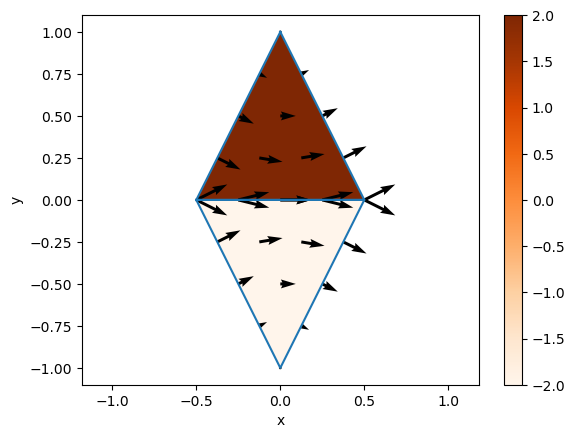

In [13]:
Ω = generate_refpair()
X = Nedelec(Ω)
plt = plotfield(X, [1.0])
display(plt)

# TE-modes of a rectangular waveguide

Recall that we look for the solutions to
\begin{align}
    \nabla \times \nabla \times \mathbf E_\mathrm{t} - k^2 \mathbf E_\mathrm{t} &= \mathbf{0} \quad \mathbf{r} \in \Omega = [-2,2] \times [-1, 1] \\
    \hat{\mathbf{n}} \times \mathbf E_\mathrm{t} &= \mathbf{0} \quad \mathbf{r} \in \partial\Omega
\end{align}

By enforcing that $\mathbf{E}$ is a tangential vector field (i.e., orthogonal with respect to $\hat{\mathbf{z}}$), we ensure that we obtain transverse electric (TE) modes, that is, electric fields, where $\mathbf{E}_z = 0$. Using Nedelec functions $\mathbf{N}_i$, we automatically enforce the tangential nature.

The analytic solutions for $k_{mn}^2$ corresponding to the $\mathrm{TE}_{mn}$-mode are given by
\begin{equation}
    k_{mn}^2 = \left(\frac{m\pi}{a}\right)^2 + \left(\frac{n\pi}{b}\right)^2
\end{equation}

In [14]:
ksquare(m, n, a, b) = (m*π/a)^2 + (n*π/b)^2 
function compute_eigenvalues(a, b, h)
    # Create a mesh
    generate_rectangle(a, b, h)
    
    Ω = read_gmsh("rectangle.msh")
    
    X = Nedelec(Ω)
    
    S, M = assemble(X)
    
    λ, V = eigen(S, M)
    
    rank_S = length(findall(x -> x > 0.001, abs.(λ)))
    rank_M = size(M, 1)
    return λ, V, X, rank_M - rank_S
end
a = 4
b = 2
λ, V, X, dim_nullspace = compute_eigenvalues(a, b, 1)

([-2.4489117339117873e-14, -1.654954483848092e-14, -1.5533279029274604e-14, -1.3802441091460927e-14, -1.3183046664213711e-14, -1.2090594036486924e-14, -9.551640619308883e-15, -9.536880792094316e-15, -9.400088625105971e-15, -9.249392801930113e-15  …  228.0783406010652, 236.96872030743498, 237.99054817708634, 255.24818008332437, 264.29137197551955, 264.4522711053753, 280.04298498825494, 280.8069753158224, 286.08895402987133, 293.37883817981685], [-1.0 0.03866314653716462 … -0.008703490489333957 0.5074695871642988; -0.3596798040828617 0.177280885722978 … 0.0019459330148615742 -0.11322898733732598; … ; 0.005266404505469588 0.16023521971525556 … 0.000383333528991791 -0.010119480005557588; 0.0013827460379628991 0.5986498181852666 … -0.02360030310516504 -9.993204436620088e-5], Nedelec{Mesh{3, 3, Int64, Float64}, Int64, Float64}(Mesh{3, 3, Int64, Float64}(SVector{3, Float64}[[2.0, 1.0, 0.0], [-2.0, 1.0, 0.0], [-2.0, -1.0, 0.0], [2.0, -1.0, 0.0], [1.555555555556788, 1.0, 0.0], [1.11111111111357

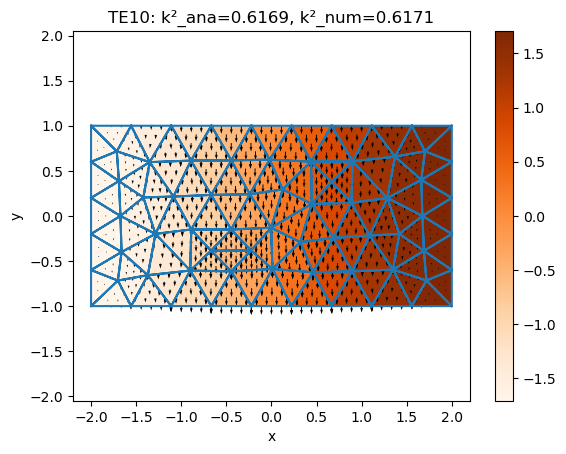

PyObject <matplotlib.quiver.Quiver object at 0x7f7875f16d10>

In [15]:
idx = dim_nullspace + 1
m = 1; n = 0
λ_num = @sprintf("%.4f", abs(λ[idx]))
λ_ana = @sprintf("%.4f", ksquare(m, n, a, b)) 
plotfield(X, V[:, idx], plottitle="TE$m$n: k²_ana=$λ_ana, k²_num=$λ_num")

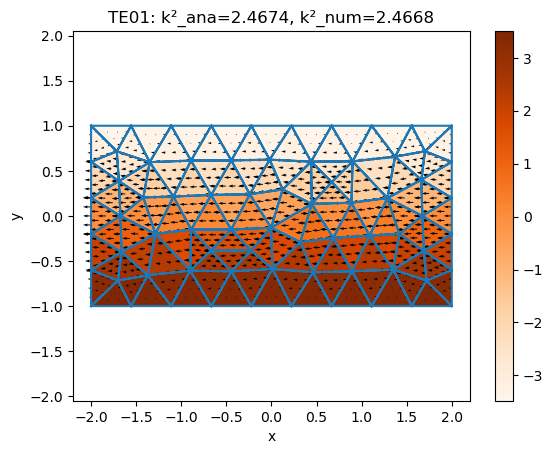

PyObject <matplotlib.quiver.Quiver object at 0x7f7875fcba00>

In [16]:
idx = dim_nullspace + 2
m = 0; n = 1
λ_num = @sprintf("%.4f", abs(λ[idx]))
λ_ana = @sprintf("%.4f", ksquare(m, n, a, b)) 
plotfield(X, V[:, idx], plottitle="TE$m$n: k²_ana=$λ_ana, k²_num=$λ_num")

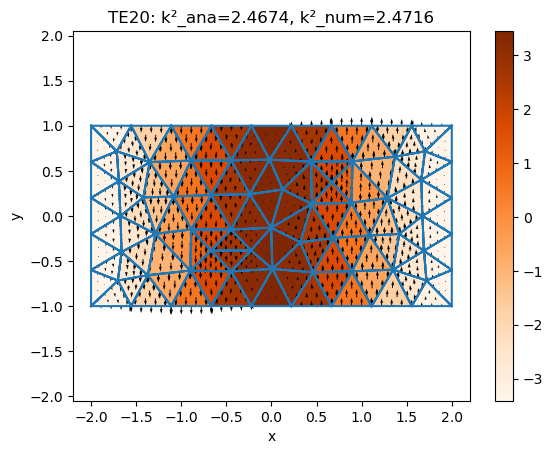

PyObject <matplotlib.quiver.Quiver object at 0x7f786db531c0>

In [17]:
idx = dim_nullspace + 3
m = 2; n = 0
λ_num = @sprintf("%.4f", abs(λ[idx]))
λ_ana = @sprintf("%.4f", ksquare(m, n, a, b)) 
plotfield(X, V[:, idx], plottitle="TE$m$n: k²_ana=$λ_ana, k²_num=$λ_num")

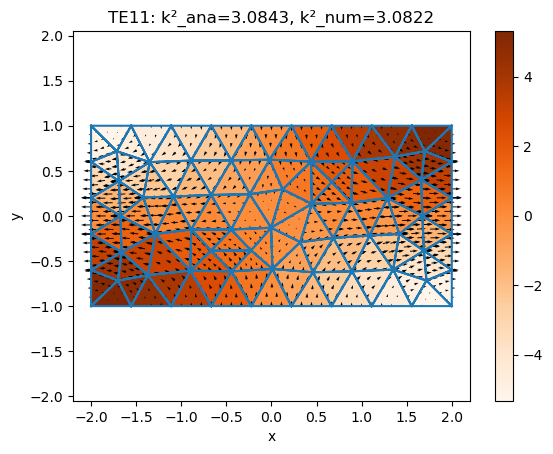

PyObject <matplotlib.quiver.Quiver object at 0x7f786d873700>

In [18]:
idx = dim_nullspace + 4
m = 1; n = 1
λ_num = @sprintf("%.4f", abs(λ[idx]))
λ_ana = @sprintf("%.4f", ksquare(m, n, a, b)) 
plotfield(X, V[:, idx], plottitle="TE$m$n: k²_ana=$λ_ana, k²_num=$λ_num")

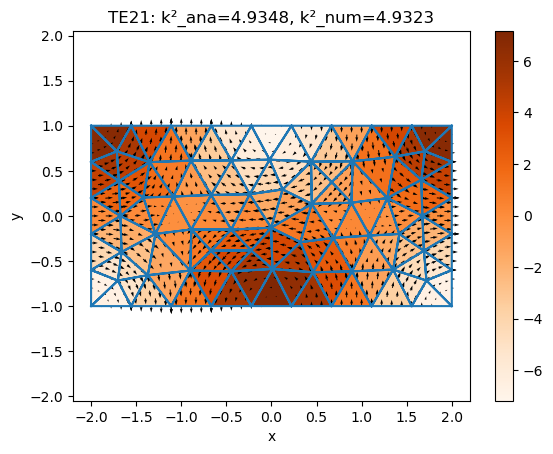

PyObject <matplotlib.quiver.Quiver object at 0x7f786db0b3a0>

In [19]:
idx = dim_nullspace + 5
m = 2; n = 1
λ_num = @sprintf("%.4f", abs(λ[idx]))
λ_ana = @sprintf("%.4f", ksquare(m, n, a, b)) 
plotfield(X, V[:, idx], plottitle="TE$m$n: k²_ana=$λ_ana, k²_num=$λ_num")

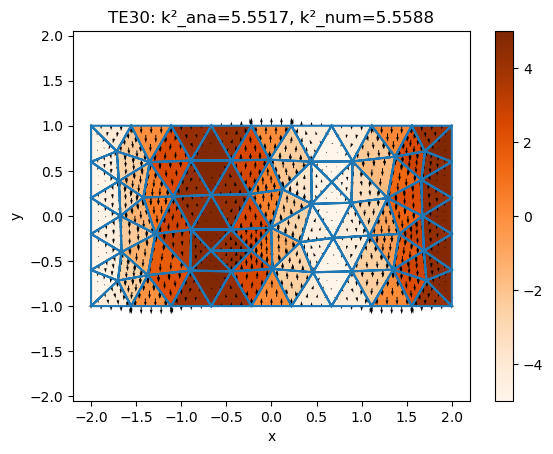

PyObject <matplotlib.quiver.Quiver object at 0x7f786d60f940>

In [20]:
idx = dim_nullspace + 6
m = 3; n = 0
λ_num = @sprintf("%.4f", abs(λ[idx]))
λ_ana = @sprintf("%.4f", ksquare(m, n, a, b)) 
plotfield(X, V[:, idx], plottitle="TE$m$n: k²_ana=$λ_ana, k²_num=$λ_num")